<a href="https://colab.research.google.com/github/Sinchana-2208/my_projects/blob/main/SinchanaShetty_MajorProject_Health_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving CVD_cleaned.csv to CVD_cleaned (2).csv


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [ ]:
#loading the dataset
df = pd.read_csv("CVD_cleaned.csv")

df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0


In [ ]:
#checking the dataset
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  object 
 1   Checkup                       308854 non-null  object 
 2   Exercise                      308854 non-null  object 
 3   Heart_Disease                 308854 non-null  object 
 4   Skin_Cancer                   308854 non-null  object 
 5   Other_Cancer                  308854 non-null  object 
 6   Depression                    308854 non-null  object 
 7   Diabetes                      308854 non-null  object 
 8   Arthritis                     308854 non-null  object 
 9   Sex                           308854 non-null  object 
 10  Age_Category                  308854 non-null  object 
 11  Height_(cm)                   308854 non-null  int64  
 12  Weight_(kg)                   308854 non-nul

,0
General_Health,0
Checkup,0
Exercise,0
Heart_Disease,0
Skin_Cancer,0
Other_Cancer,0
Depression,0
Diabetes,0
Arthritis,0
Sex,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for column in df.columns:
    if df[column].dtype == 'object':
        label_encoders[column] = LabelEncoder()
        df[column] = label_encoders[column].fit_transform(df[column])

df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,3,2,0,0,0,0,0,0,1,0,10,150,32.66,14.54,1,0,30,16,12
1,4,4,0,1,0,0,0,2,0,0,10,165,77.11,28.29,0,0,30,0,4
2,4,4,1,0,0,0,0,2,0,0,8,163,88.45,33.47,0,4,12,3,16
3,3,4,1,1,0,0,0,2,0,1,11,180,93.44,28.73,0,0,30,30,8
4,2,4,0,0,0,0,0,0,0,1,12,191,88.45,24.37,1,0,8,4,0


In [ ]:
#separating target column
X = df.drop("General_Health", axis=1)

y = df["General_Health"]

In [ ]:
#splitting test and target
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
print(df.shape)

(308854, 19)


In [ ]:
#training support vector machine model
from sklearn.svm import LinearSVC

svm = LinearSVC(
    C=1.0,
    max_iter=5000,
    random_state=42
)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

SVM Accuracy : 0.4156481196678053

Classification Report

              precision    recall  f1-score   support

           0       0.39      0.02      0.04     11191
           1       0.38      0.03      0.05      7162
           2       0.40      0.42      0.41     19073
           3       0.00      0.00      0.00      2266
           4       0.42      0.78      0.55     22079

    accuracy                           0.42     61771
   macro avg       0.32      0.25      0.21     61771
weighted avg       0.39      0.42      0.34     61771



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


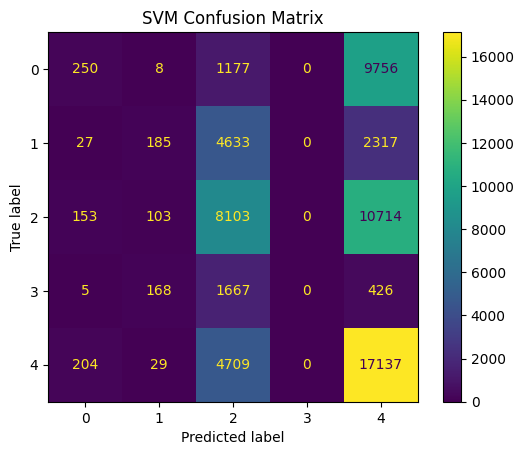

In [ ]:
#SVM results
svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy :", svm_accuracy)

print("\nClassification Report\n")

print(classification_report(y_test, svm_pred))

ConfusionMatrixDisplay.from_predictions(y_test, svm_pred)

plt.title("SVM Confusion Matrix")

plt.show()

In [ ]:
#training random forest model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

Random Forest Accuracy : 0.40679283158763824
              precision    recall  f1-score   support

           0       0.39      0.25      0.30     11191
           1       0.34      0.18      0.24      7162
           2       0.39      0.46      0.42     19073
           3       0.34      0.09      0.14      2266
           4       0.43      0.55      0.48     22079

    accuracy                           0.41     61771
   macro avg       0.38      0.30      0.32     61771
weighted avg       0.40      0.41      0.39     61771



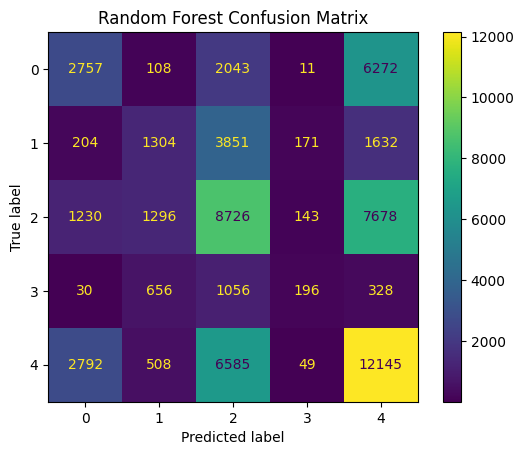

In [ ]:
#random forest result
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", rf_accuracy)

print(classification_report(y_test, rf_pred))

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
#training logistic regression model
lr = LogisticRegression(
    max_iter=2000,
    random_state=42,
    n_jobs=-1
)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

Logistic Regression Accuracy : 0.42272263683605577
              precision    recall  f1-score   support

           0       0.45      0.13      0.21     11191
           1       0.36      0.12      0.19      7162
           2       0.41      0.43      0.42     19073
           3       0.41      0.05      0.09      2266
           4       0.43      0.70      0.53     22079

    accuracy                           0.42     61771
   macro avg       0.41      0.29      0.29     61771
weighted avg       0.42      0.42      0.38     61771



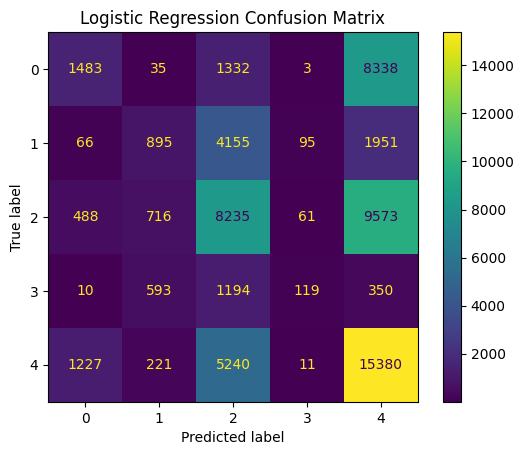

In [ ]:
#logistic regression result
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", lr_accuracy)

print(classification_report(y_test, lr_pred))

ConfusionMatrixDisplay.from_predictions(y_test, lr_pred)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

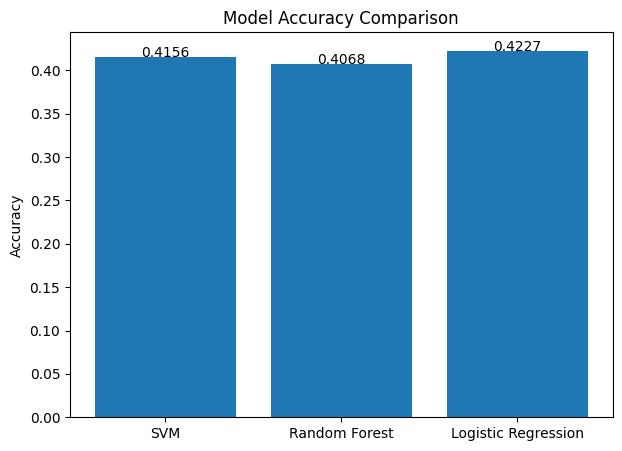

In [ ]:
#comparing the accuracy of the models
models = ["SVM", "Random Forest", "Logistic Regression"]

accuracies = [
    svm_accuracy,
    rf_accuracy,
    lr_accuracy
]

plt.figure(figsize=(7,5))

bars = plt.bar(models, accuracies)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.4f}",
        ha='center'
    )

plt.show()

In [ ]:
#randomized grid search for SVM
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV

svm_params = {
    'C': [0.01, 0.1, 1, 10],
    'max_iter': [3000, 5000]
}

svm_search = RandomizedSearchCV(
    estimator=LinearSVC(random_state=42),
    param_distributions=svm_params,
    n_iter=3,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

svm_search.fit(X_train, y_train)

print("Best Parameters:", svm_search.best_params_)
print("Best Accuracy:", svm_search.best_score_)

Best Parameters: {'max_iter': 5000, 'C': 0.01}
Best Accuracy: 0.4154717240765249


In [ ]:
#randomised grid search for random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=5,          # Only 5 combinations
    cv=3,              # 3-fold CV
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best Parameters:", rf_search.best_params_)
print("Best Accuracy:", rf_search.best_score_)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}
Best Accuracy: 0.4262535261430369


In [ ]:
#randomised grid search for logistic regression
lr_params = {
    'C':[0.1,1,10],
    'solver':['lbfgs'],
    'max_iter':[2000]
}

lr_search = RandomizedSearchCV(
    LogisticRegression(),
    lr_params,
    n_iter=3,
    cv=3,
    random_state=42,
    scoring='accuracy',
    n_jobs=-1
)

lr_search.fit(X_train, y_train)

print(lr_search.best_params_)

print(lr_search.best_score_)


{'solver': 'lbfgs', 'max_iter': 2000, 'C': 0.1}
0.4234042811524872


In [ ]:
#  AI Health Prediction System

patient_number = int(input(f"Enter Patient Index (0 to {len(X)-1}): "))

if patient_number < 0 or patient_number >= len(X):
    print("Invalid Patient Index!")
else:
    sample = X.iloc[[patient_number]]

    sample_scaled = scaler.transform(sample)

    prediction = rf.predict(sample_scaled)

    predicted_health = label_encoders["General_Health"].inverse_transform(prediction)

    print("\n===================================")
    print("       AI HEALTH PREDICTION")
    print("===================================")
    print(f"Patient Index           : {patient_number}")
    print(f"Predicted Health Status : {predicted_health[0]}")
    print("===================================")

Enter Patient Index (0 to 308853): 456

       AI HEALTH PREDICTION
Patient Index           : 456
Predicted Health Status : Fair
